# Regime Adaptive Portfolio ÔÇØExploration

This notebook walks through the three core components of the project:
1. HMM regime detection  what the model learned and when it detected each regime
2. Optimizer comparison  how each optimizer allocates across assets
3. Backtest results  equity curve, drawdown, and performance metrics


In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

REGIME_COLORS = {"Bull": "#2ecc71", "Bear": "#e74c3c", "Sideways": "#f39c12"}


## 1. Regime Detection

The HMM labels each trading day as Bull, Bear, or Sideways based on three features:
- **SPY log return**  daily return signal
- **Rolling volatility**  21-day annualized volatility
- **Rolling correlation** ├ó 63-day mean pairwise correlation across assets

In [3]:
# Load data
regimes = pd.read_parquet("../data/regimes.parquet")
features = pd.read_parquet("../data/processed/features.parquet")
returns = pd.read_parquet("../data/processed/returns.parquet")

print(f"Date range: {regimes.index.min().date()} to {regimes.index.max().date()}")
print(f"Regime counts:\n{regimes['regime'].value_counts()}")

Date range: 2005-04-05 to 2024-12-30
Regime counts:
regime
Bull        1772
Bear        1356
Sideways    1248
Crash        593
Name: count, dtype: int64


### 1.1 Regime Timeline

How the HMM classified each day over the full 20-year period.

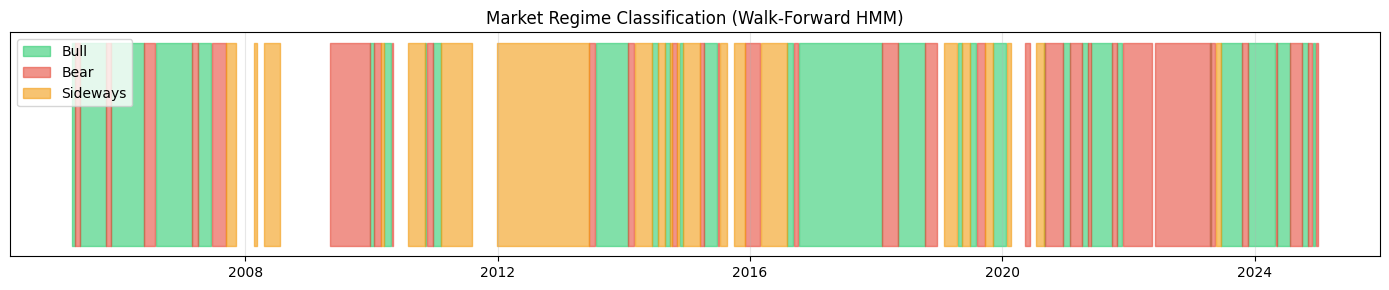

In [4]:
fig, ax = plt.subplots(figsize=(14, 3))

for regime, color in REGIME_COLORS.items():
    mask = regimes["regime"] == regime
    ax.fill_between(regimes.index, 0, 1,
                    where=mask,
                    color=color, alpha=0.6,
                    label=regime)

ax.set_yticks([])
ax.set_title("Market Regime Classification (Walk-Forward HMM)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 1.2 Feature Distributions by Regime

What each regime looks like in terms of the three input features.

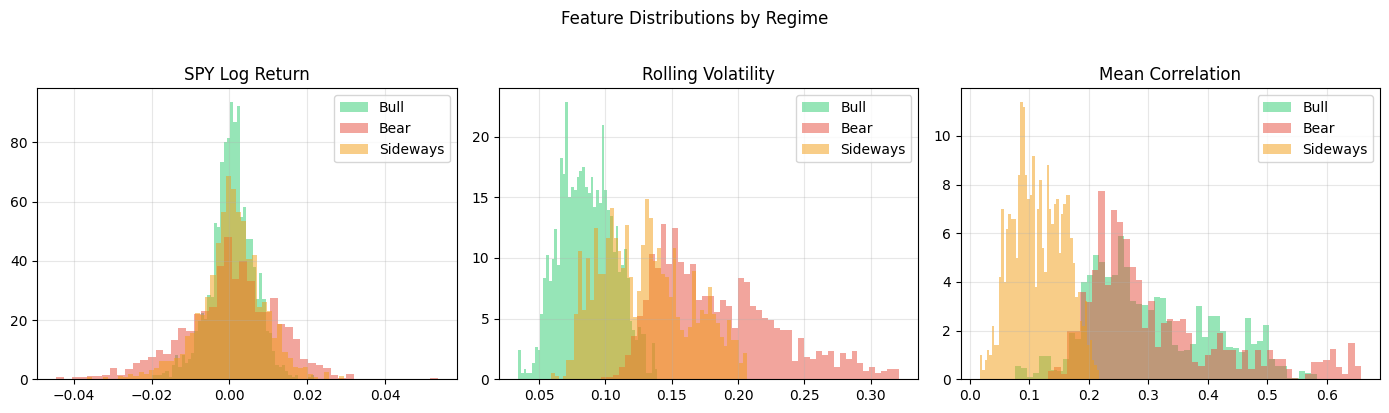

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features_aligned = features.loc[regimes.index]
features_aligned["regime"] = regimes["regime"]

feature_cols = {
    "spy_return": "SPY Log Return",
    "spy_vol": "Rolling Volatility",
    "mean_corr": "Mean Correlation"
}

for ax, (col, label) in zip(axes, feature_cols.items()):
    for regime, color in REGIME_COLORS.items():
        subset = features_aligned[features_aligned["regime"] == regime][col]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=regime, density=True)
    ax.set_title(label)
    ax.legend()

plt.suptitle("Feature Distributions by Regime", y=1.02)
plt.tight_layout()
plt.show()

## 2. Optimizer Comparison

Each regime triggers a different optimizer. Here we compare the resulting asset allocations.

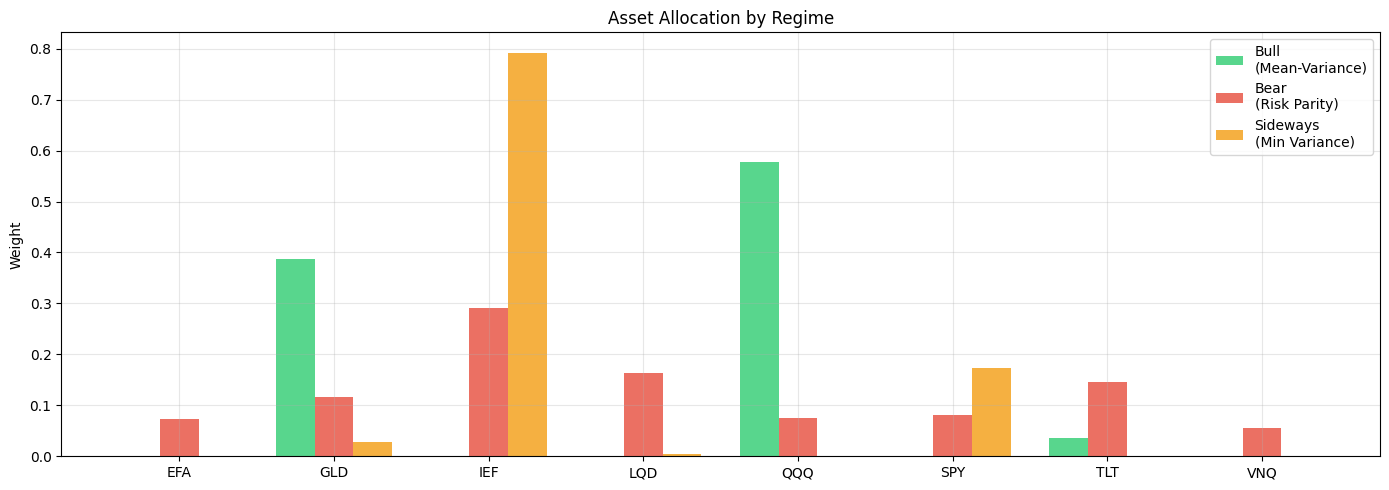

In [6]:
from optimization.mean_var import max_sharpe
from optimization.risk_parity import risk_parity
from optimization.min_variance import min_variance

assets = returns.columns.tolist()

w_bull     = max_sharpe(returns)
w_bear     = risk_parity(returns)
w_sideways = min_variance(returns)

labels = ["Bull\n(Mean-Variance)", "Bear\n(Risk Parity)", "Sideways\n(Min Variance)"]
weights = [w_bull, w_bear, w_sideways]
colors  = [REGIME_COLORS["Bull"], REGIME_COLORS["Bear"], REGIME_COLORS["Sideways"]]

x = np.arange(len(assets))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (w, label, color) in enumerate(zip(weights, labels, colors)):
    ax.bar(x + i * width, w, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(assets)
ax.set_ylabel("Weight")
ax.set_title("Asset Allocation by Regime")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Backtest Results

Portfolio performance versus SPY buy-and-hold over the full period.

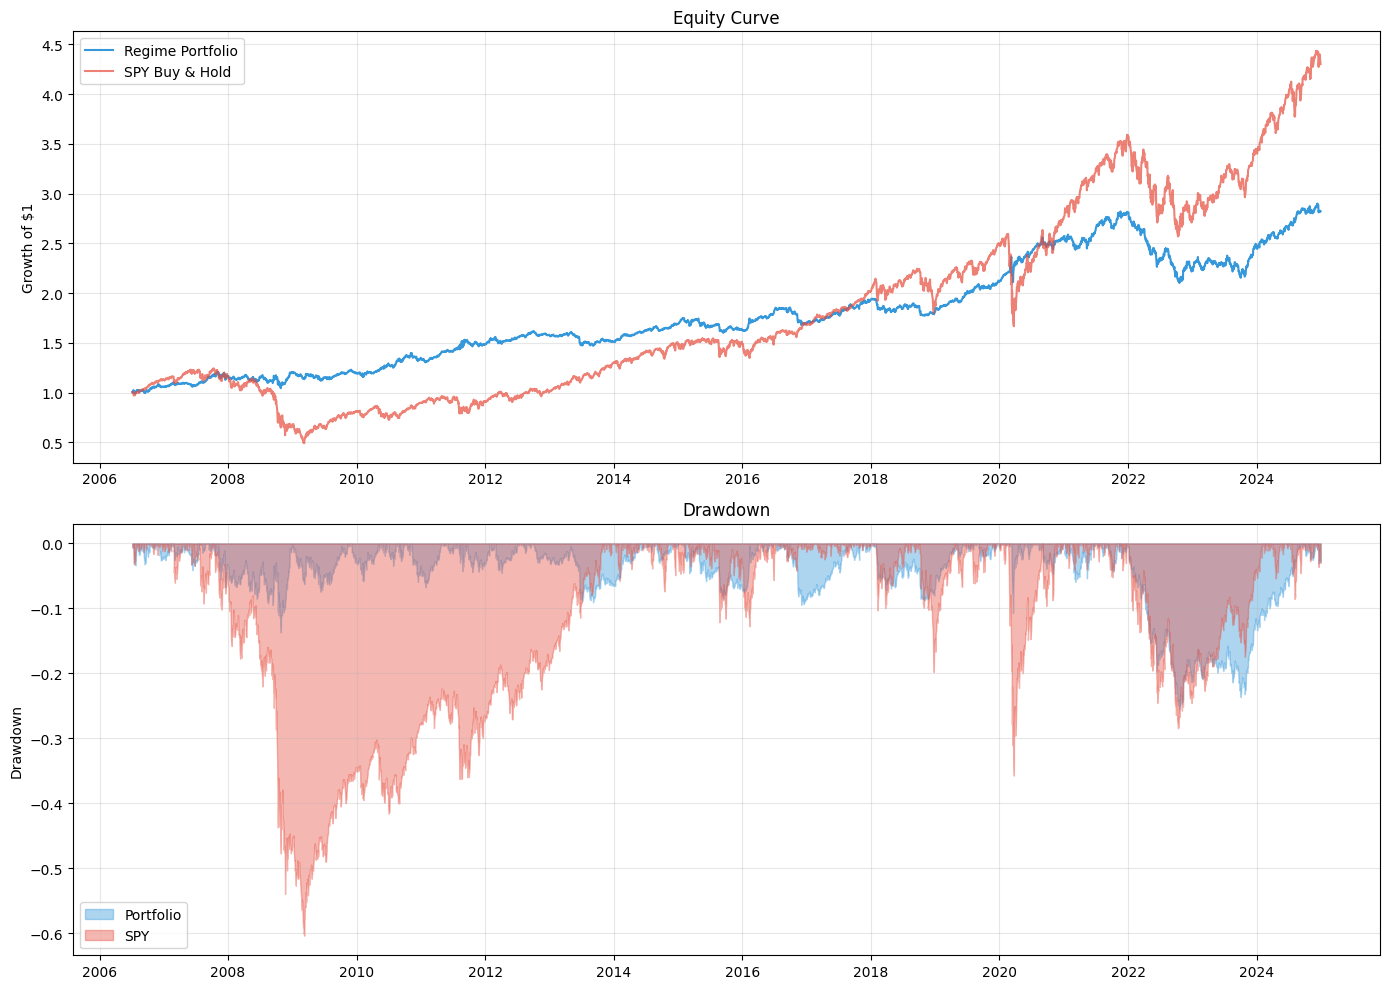

In [7]:
backtest = pd.read_parquet("../data/backtest_results.parquet")

common = backtest.index.intersection(returns.index)
spy_returns = returns.loc[common, "SPY"]
spy_equity = (1 + spy_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Equity curves
axes[0].plot(backtest["equity"], label="Regime Portfolio", color="#3498db", linewidth=1.5)
axes[0].plot(spy_equity, label="SPY Buy & Hold", color="#e74c3c", linewidth=1.5, alpha=0.7)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

# Drawdown
port_dd = (backtest["equity"] - backtest["equity"].cummax()) / backtest["equity"].cummax()
spy_dd  = (spy_equity - spy_equity.cummax()) / spy_equity.cummax()

axes[1].fill_between(port_dd.index, port_dd, 0, alpha=0.4, color="#3498db", label="Portfolio")
axes[1].fill_between(spy_dd.index, spy_dd, 0, alpha=0.4, color="#e74c3c", label="SPY")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.1 Performance Metrics

In [8]:
from backtest.metrics import compute_all

port_metrics = compute_all(backtest["portfolio_return"], backtest["equity"])
spy_metrics  = compute_all(spy_returns, spy_equity)

metrics_df = pd.DataFrame({
    "Portfolio": port_metrics,
    "SPY": spy_metrics
})

metrics_df.index = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Calmar Ratio"
]

metrics_df

,Portfolio,SPY
Annualized Return,0.0579,0.0827
Annualized Volatility,0.0871,0.1958
Sharpe Ratio,0.2057,0.2179
Max Drawdown,-0.2549,-0.6039
Calmar Ratio,0.2272,0.1369


## 4. Posterior Probability Blending (v2)

In v2, the HMM outputs a full probability distribution over states for every day.
Instead of hard-switching to a single optimizer, weights are blended by posterior:

```
weights(t) = P(Bull|t) * w_bull + P(Bear|t) * w_bear + P(Sideways|t) * w_sideways
```

This is model-driven uncertainty ÔÇö the HMM's own confidence controls how aggressively we rotate.

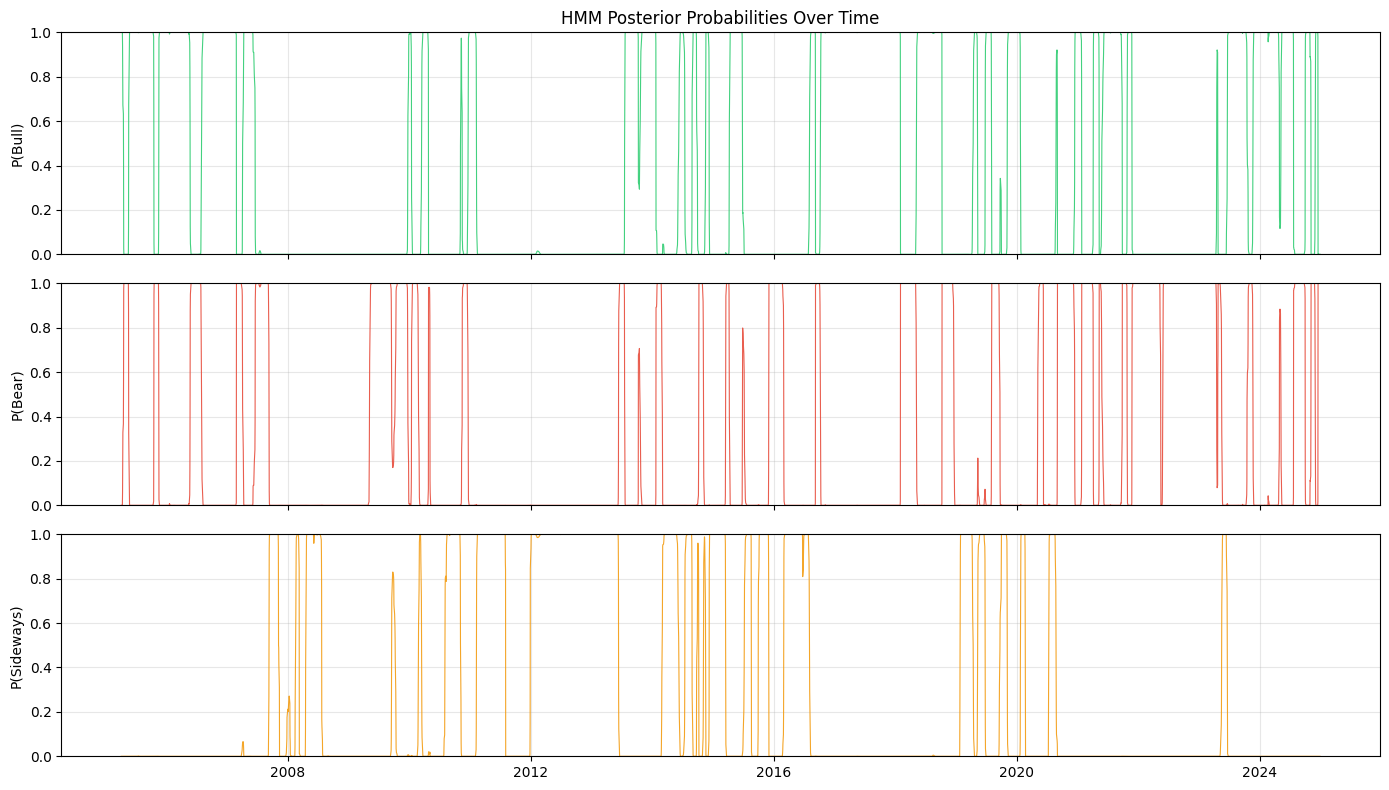

In [9]:
regimes = pd.read_parquet('../data/regimes.parquet')

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, (col, label, color) in zip(axes, [
    ('p_bull',     'P(Bull)',     '#2ecc71'),
    ('p_bear',     'P(Bear)',     '#e74c3c'),
    ('p_sideways', 'P(Sideways)', '#f39c12')
]):
    ax.plot(regimes.index, regimes[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1)

axes[0].set_title('HMM Posterior Probabilities Over Time')
plt.tight_layout()
plt.show()

## 5. BIC/AIC State Selection (v2)

The choice of n=3 states is validated using out-of-sample scoring.
Models with 2ÔÇô5 states are trained on 80% of the data and scored on the held-out 20%.
Both AIC and BIC show a clean minimum at n=3 ÔÇö more states overfit the training period.

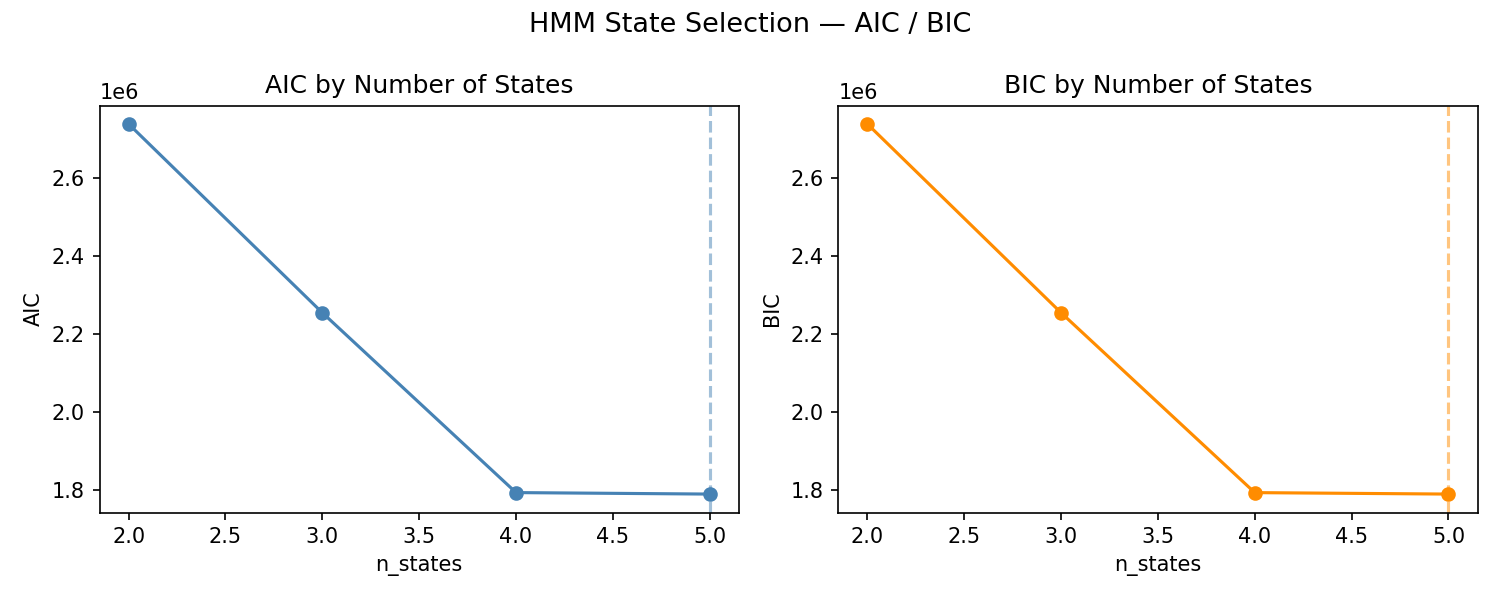

In [10]:
from IPython.display import Image
Image('../data/state_selection.png')

## 6. Expanded Benchmark Comparison (v2)

SPY alone is a weak baseline ÔÇö it carries full equity volatility.
v2 compares against Equal Weight, 60/40 (SPY + IEF), and 12-month Momentum.

In [11]:
from backtest.benchmark import (
    get_equal_weight_equity,
    get_sixty_forty_equity,
    get_momentum_equity
)
from backtest.metrics import compute_all

backtest = pd.read_parquet('../data/backtest_results.parquet')
returns  = pd.read_parquet('../data/processed/returns.parquet')
common   = returns.index.intersection(backtest.index)
returns  = returns.loc[common]

spy_returns        = returns['SPY']
spy_equity         = (1 + spy_returns).cumprod()
ew_returns,  ew_equity  = get_equal_weight_equity(returns)
sf_returns,  sf_equity  = get_sixty_forty_equity(returns)
mom_returns, mom_equity = get_momentum_equity(returns)

metrics_df = pd.DataFrame({
    'Portfolio':    compute_all(backtest['portfolio_return'], backtest['equity']),
    'SPY':          compute_all(spy_returns, spy_equity),
    'Equal Weight': compute_all(ew_returns, ew_equity),
    '60/40':        compute_all(sf_returns, sf_equity),
    'Momentum':     compute_all(mom_returns, mom_equity),
})

metrics_df.index = [
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'Calmar Ratio'
]

metrics_df

,Portfolio,SPY,Equal Weight,60/40,Momentum
Annualized Return,0.0579,0.0827,0.0590,0.0680,0.0576
Annualized Volatility,0.0871,0.1958,0.1119,0.1120,0.1322
Sharpe Ratio,0.2057,0.2179,0.1697,0.2497,0.1331
Max Drawdown,-0.2549,-0.6039,-0.3529,-0.3621,-0.2961
Calmar Ratio,0.2272,0.1369,0.1671,0.1877,0.1945


## 7. Block Bootstrap Significance Test (v2)

Is the Sharpe outperformance statistically significant?

Block bootstrap with 1000 iterations and 20-day blocks preserves the autocorrelation
structure of financial returns. The p-value measures how often SPY beats the portfolio
in synthetic resampled runs.

In [12]:
from backtest.bootstrap import run_bootstrap, summarize

backtest    = pd.read_parquet('../data/backtest_results.parquet')
returns     = pd.read_parquet('../data/processed/returns.parquet')
common      = returns.index.intersection(backtest.index)
spy_returns  = returns.loc[common, 'SPY']
port_returns = backtest.loc[common, 'portfolio_return']

bootstrap_df = run_bootstrap(port_returns, spy_returns)
summary      = summarize(bootstrap_df)

pd.Series(summary)

mean_sharpe_diff    -0.0112
std_sharpe_diff      0.3219
ci_lower            -0.6291
ci_upper             0.6032
p_value               0.527
significant_at_95     False
dtype: object

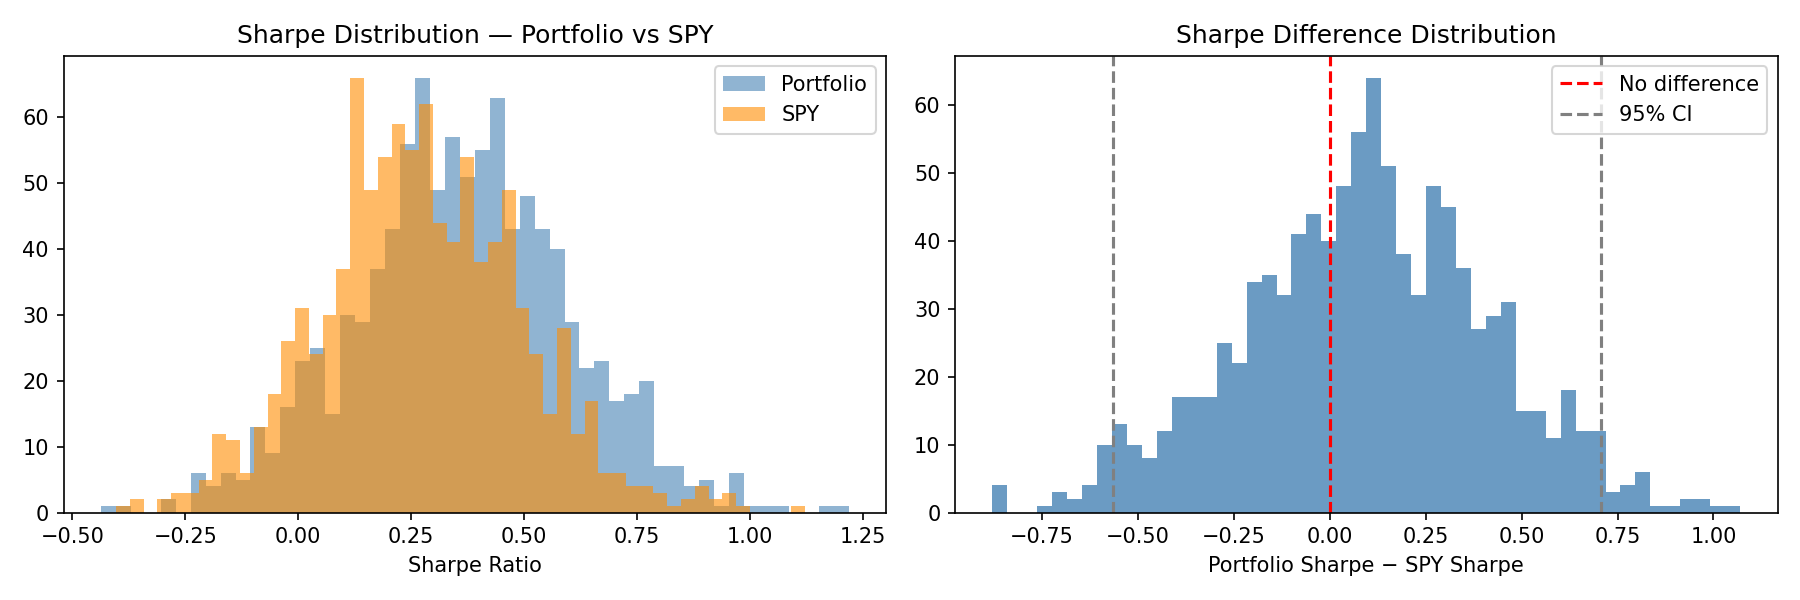

In [13]:
Image('../data/bootstrap.png')

## 8. Regime Transition Matrix & Persistence (v2)

The HMM transition matrix shows the probability of moving between regimes day-to-day.
High diagonal values confirm regime persistence — a core assumption of the HMM approach.

Average duration per regime is derived from the diagonal: `1 / (1 - A[i][i])`

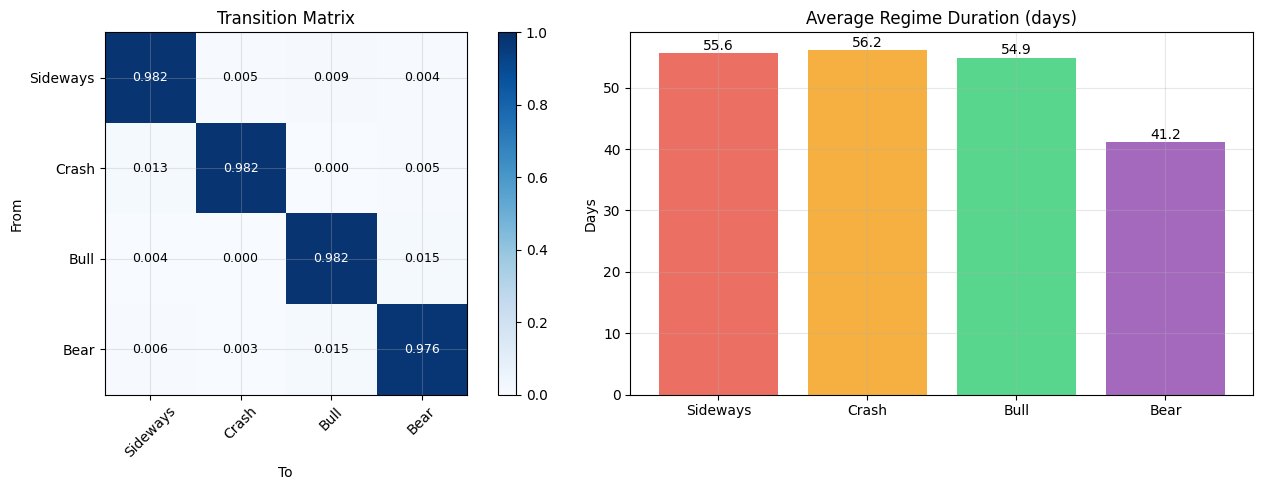

In [16]:
from models.hmm import load_model, load_features, label_states, get_transition_matrix, get_regime_durations
import matplotlib.pyplot as plt
import matplotlib
import os
os.chdir("..")  # move to project root if running from notebooks/

model, scaler = load_model()
df = load_features()
state_labels = label_states(model, df)
transmat = get_transition_matrix(model, state_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(transmat.values, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(transmat.columns)))
axes[0].set_yticks(range(len(transmat.index)))
axes[0].set_xticklabels(transmat.columns, rotation=45)
axes[0].set_yticklabels(transmat.index)
axes[0].set_title('Transition Matrix')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')
plt.colorbar(im, ax=axes[0])

for i in range(len(transmat.index)):
    for j in range(len(transmat.columns)):
        val = transmat.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=9)

# Duration bar chart
durations = get_regime_durations(transmat)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#8e44ad']
axes[1].bar(durations.index, durations.values, color=colors, alpha=0.8)
axes[1].set_title('Average Regime Duration (days)')
axes[1].set_ylabel('Days')
for i, (regime, val) in enumerate(durations.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
print('Transition Matrix:')
print(transmat.round(4))
print('\nAverage Regime Durations (days):')
print(get_regime_durations(transmat))

Transition Matrix:
          Sideways   Crash    Bull    Bear
Sideways    0.9820  0.0053  0.0087  0.0040
Crash       0.0127  0.9822  0.0000  0.0051
Bull        0.0036  0.0000  0.9818  0.0146
Bear        0.0064  0.0030  0.0149  0.9758

Average Regime Durations (days):
Sideways    55.6
Crash       56.2
Bull        54.9
Bear        41.2
Name: avg_duration_days, dtype: float64


## 8. Regime Transition Matrix & Persistence (v2)

The HMM transition matrix shows the probability of moving between regimes day-to-day.
High diagonal values confirm regime persistence — a core assumption of the HMM approach.

Average duration per regime is derived from the diagonal: `1 / (1 - A[i][i])`

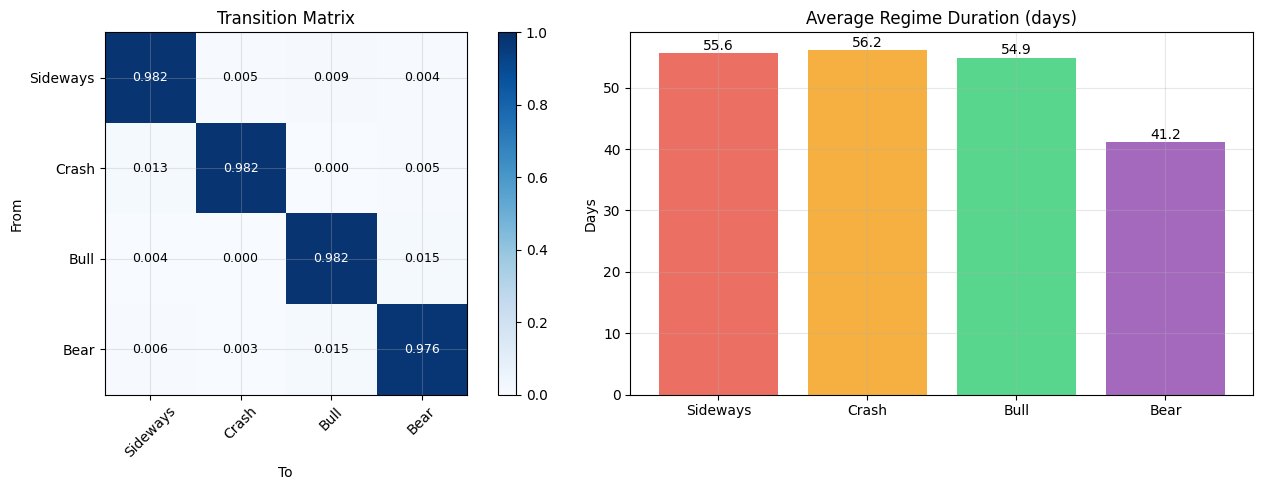

In [18]:
from models.hmm import load_model, load_features, label_states, get_transition_matrix, get_regime_durations
import matplotlib.pyplot as plt
import matplotlib
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

model, scaler = load_model()
df = load_features()
state_labels = label_states(model, df)
transmat = get_transition_matrix(model, state_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(transmat.values, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(transmat.columns)))
axes[0].set_yticks(range(len(transmat.index)))
axes[0].set_xticklabels(transmat.columns, rotation=45)
axes[0].set_yticklabels(transmat.index)
axes[0].set_title('Transition Matrix')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')
plt.colorbar(im, ax=axes[0])

for i in range(len(transmat.index)):
    for j in range(len(transmat.columns)):
        val = transmat.values[i, j]
        color = 'white' if val > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=9)

# Duration bar chart
durations = get_regime_durations(transmat)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#8e44ad']
axes[1].bar(durations.index, durations.values, color=colors, alpha=0.8)
axes[1].set_title('Average Regime Duration (days)')
axes[1].set_ylabel('Days')
for i, (regime, val) in enumerate(durations.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
print('Transition Matrix:')
print(transmat.round(4))
print('\nAverage Regime Durations (days):')
print(get_regime_durations(transmat))

Transition Matrix:
          Sideways   Crash    Bull    Bear
Sideways    0.9820  0.0053  0.0087  0.0040
Crash       0.0127  0.9822  0.0000  0.0051
Bull        0.0036  0.0000  0.9818  0.0146
Bear        0.0064  0.0030  0.0149  0.9758

Average Regime Durations (days):
Sideways    55.6
Crash       56.2
Bull        54.9
Bear        41.2
Name: avg_duration_days, dtype: float64
